# Prerequisites

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')

## Main df

In [2]:
# Import data
df_main_old = pd.read_excel('../data/old_df_main.xlsx', index_col=0).reset_index(drop=True)
## Drop unused columns
# drop_columns = ['voltage', 'long_impulse_duration', 'long_impulse_dur_binary']
# df_main_old = df_main_old.drop(drop_columns, axis=1)
display(df_main_old.head())
df_main_old.info()

,test,one_drop,splashing,breaking_up,net_impact,rebound,voltage,long_impulse_duration,height,inclination,...,roughness,long_impulse_dur_binary,roughness_binary,volume_fraction_binary,velocity,Re,We,We_Re,particle_droplet_diameter_ratio,particle_diameter_cat
0,3,1,1,0,0,0,105.0,10,0.8,0,...,0.10,low,0,1,3.961141,1492.516020,1492.302356,240.108847,0.013301,small
1,4,1,1,0,0,0,105.0,10,0.8,0,...,0.10,low,0,1,3.961141,1492.516020,1492.302356,240.108847,0.013301,small
2,5,1,1,0,0,0,105.0,10,0.8,0,...,0.10,low,0,1,3.961141,1492.516020,1492.302356,240.108847,0.013301,small
3,7,0,1,0,0,0,105.0,10,0.8,0,...,0.04,low,0,1,3.961141,1435.111557,1434.906112,233.148786,0.013833,small
4,8,0,1,0,0,0,105.0,10,0.8,0,...,0.04,low,0,1,3.961141,1435.111557,1434.906112,233.148786,0.013833,small


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372 entries, 0 to 371
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   test                             372 non-null    int64  
 1   one_drop                         372 non-null    int64  
 2   splashing                        372 non-null    int64  
 3   breaking_up                      372 non-null    int64  
 4   net_impact                       372 non-null    int64  
 5   rebound                          372 non-null    int64  
 6   voltage                          372 non-null    float64
 7   long_impulse_duration            372 non-null    int64  
 8   height                           372 non-null    float64
 9   inclination                      372 non-null    int64  
 10  droplet_diameter                 372 non-null    float64
 11  liquid_density                   372 non-null    int64  
 12  surface_tension       

Labels before label editing

In [3]:
label_name = ['net_impact', 'splashing', 'breaking_up', 'rebound']

class_count_dict = {}

for label in label_name:
    class_count_dict[label] = df_main_old[df_main_old[label]==1].shape[0]

class_count_s = pd.Series(class_count_dict)
class_count_s

net_impact     121
splashing      174
breaking_up    101
rebound         99
dtype: int64

**Labels description:**
- **splashing**: when *'Number of detached small droplets during Spreading'=='many' (more than 5)*;
- **breaking_up**: combines clear "breaking_up" during receding *'Droplet Receding'==2*, as well as the Spreading detaching *0<'Number of detached small droplets during Spreading'<=5*;
- **rebound**: combines all rebound types (partial and total, *'Rebound'>0*), as well as the central jet ejection *'Rim merging or Central jet ejecting'==2*
- **net_impact**: when there is 
    - **no Splashing** (no small droplets detached during spreading, *'Number of detached small droplets during Spreading'==0*), 
    - **no Breaking up** (*'Droplet Receding'<2* [equivalent is *'Number of detached small droplets during Receding or Rim merging' == 0*])
    - **no Rebound** (*'Rebound' == 0*)

**Total count of clear experiments is *372***

## Suspension Data Labeling Edited. 
For comparison with a new one

In [4]:
df_labels_old = pd.read_excel('../data/old_Suspension Data Labeling Edited.xlsx', index_col=0)
df_labels_old = df_labels_old.drop(index=0)
# Keep only used 372 tests (without draft substrated and liquids)
df_labels_old = df_labels_old[df_labels_old['Test #'].isin(df_main_old.test.values)]
df_labels_old = df_labels_old.drop('Comments', axis=1)
df_labels_old = df_labels_old.rename({'Test #': 'test'}, axis=1)
df_labels_old['test'] = df_labels_old['test'].astype(int)
df_labels_old = df_labels_old.reset_index(drop=True)
display(df_labels_old)
df_labels_old.info()
# df_labels_old.columns

,test,Total number of dropped drops,Number of detached small droplets during Spreading,Droplet Receding,Rim merging or Central jet ejecting,Number of detached small droplets during Receding or Rim merging,Rebound,Number of detached droplets during Rebound,Final droplets count
0,3,1,many,0,0,0,0,0,1
1,4,1,many,0,0,0,0,0,1
2,5,1,many,0,0,0,0,0,1
3,7,0,many,1,0,0,0,0,2
4,8,0,many,0,0,0,0,0,2
...,...,...,...,...,...,...,...,...,...
367,391,0,0,1,2,0,2,0,0
368,392,1,3,1,1,0,0,0,1
369,393,1,2,1,1,0,0,0,3
370,394,1,0,1,1,1,0,0,2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372 entries, 0 to 371
Data columns (total 9 columns):
 #   Column                                                            Non-Null Count  Dtype 
---  ------                                                            --------------  ----- 
 0   test                                                              372 non-null    int32 
 1   Total number of dropped drops                                     372 non-null    object
 2   Number of detached small droplets during Spreading                372 non-null    object
 3   Droplet Receding                                                  372 non-null    object
 4   Rim merging or Central jet ejecting                               372 non-null    object
 5   Number of detached small droplets during Receding or Rim merging  372 non-null    object
 6   Rebound                                                           372 non-null    object
 7   Number of detached droplets during Rebound   


| Parameter name | Description | Possible values |
| --- | --- | --- |
| Total number of dropped drops | The total number of drops that fell from above | 1, 2 |
| Number of detached small droplets during *spreading* | The number of small droplets that flew out of the lamella drops in the process of spreading | 0, 1, .., 5, many |
| Droplet Receding | Presence (1,2), absence — 0 of a visible drop shrinkage, and an increase in the drop height after reaching the maximum spot diameter. 1 — the usual reduction of the main drop, 2 — the destruction of the main drop in the process of reduction | 0, 1, 2 |
| Rim merging or Central jet ejecting | The presence (1,2), absence — 0 of an explicit rim merging at the end of the shrinkage of the drop (1) and/or the reverse vertical jet (2) (against gravity) | 0, 1, 2 |
| Number of detached small droplets during *Receding or Rim merging* | The number of small droplets separating from the rim of the main drop (rim) and remaining on the substrate during the shrinkage of the drop (receding). Drops do not separate — 0, several drops, many drops — many | 0, 1, .., 5, many |
| Rebound | Presence (1,2), absence — 0 of a drop rebound after the formation of a reverse vertical jet (central jet ejecting). Partial rebound — 1, total rebound - 2 | 0, 1, 2 |
| Number of detached droplets during *Rebound* | The number of droplets separating from the reverse vertical jet (central jet) | 0, 1, .., 5, many |
| Final droplets count | The total number of droplets on the substrate, clearly separated from each other | 1, .., 5, many |

# Check boundary and outlier tests

## High-energy tests with no splashing

Let us consider non-splashing tests when We_Re larger than 150 and splashing before 150.
Do they have correct labels?

### On the boundary

In [5]:
df_main_old[(df_main_old['splashing'] == 0) & (df_main_old['We_Re']>150) & (df_main_old['We_Re']<160)]

,test,one_drop,splashing,breaking_up,net_impact,rebound,voltage,long_impulse_duration,height,inclination,...,roughness,long_impulse_dur_binary,roughness_binary,volume_fraction_binary,velocity,Re,We,We_Re,particle_droplet_diameter_ratio,particle_diameter_cat
38,51,0,0,1,0,0,106.5,12,0.8,0,...,0.10,low,0,1,3.961141,677.852440,913.477171,154.217138,0.012388,small
40,53,0,0,0,1,0,105.0,12,0.8,0,...,0.04,low,0,1,3.961141,677.852440,913.477171,154.217138,0.012388,small
41,54,0,0,0,1,0,105.0,10,0.8,0,...,0.04,low,0,1,3.961141,677.852440,913.477171,154.217138,0.012388,small
43,56,0,0,1,0,1,106.0,12,0.8,0,...,2.49,low,0,1,3.961141,677.852440,913.477171,154.217138,0.012388,small
46,59,1,0,1,0,0,107.0,12,0.8,0,...,2.49,low,0,1,3.961141,693.028241,933.928153,156.799425,0.012117,small
47,60,1,0,1,0,0,107.0,12,0.8,0,...,0.04,low,0,1,3.961141,693.028241,933.928153,156.799425,0.012117,small
49,63,0,0,0,1,0,109.0,12,0.8,0,...,0.10,low,0,1,3.961141,653.571158,880.755601,150.055157,0.012848,small
53,69,1,0,0,0,1,108.0,15,0.8,0,...,2.49,high,0,1,3.961141,682.304008,919.476126,154.976093,0.012307,small
54,70,1,0,1,0,1,103.5,21,0.8,0,...,2.49,high,0,1,3.961141,682.304008,919.476126,154.976093,0.012307,small
60,78,1,0,1,0,0,108.0,15,0.8,0,...,0.10,high,0,1,3.961141,687.969640,927.111159,155.940249,0.040441,medium


RESULT: Cases with no detached droplets were carefully checked and changed, when it was necessary

### Outliers

In [6]:
df_main_old[(df_main_old['splashing'] == 0) & (df_main_old['We_Re']>160)]

,test,one_drop,splashing,breaking_up,net_impact,rebound,voltage,long_impulse_duration,height,inclination,...,roughness,long_impulse_dur_binary,roughness_binary,volume_fraction_binary,velocity,Re,We,We_Re,particle_droplet_diameter_ratio,particle_diameter_cat
8,16,1,0,1,0,0,103.0,18,0.8,0,...,0.10,high,0,1,3.961141,11274.017403,634.484896,259.555550,0.046453,medium
9,17,0,0,1,0,0,103.0,21,0.8,0,...,0.10,high,0,1,3.961141,11559.676628,650.561372,264.472523,0.045305,medium
10,18,0,0,1,0,0,103.0,18,0.8,0,...,0.04,high,0,1,3.961141,11559.676628,650.561372,264.472523,0.045305,medium
11,19,0,0,0,1,0,103.0,18,0.8,0,...,0.04,high,0,1,3.961141,11559.676628,650.561372,264.472523,0.045305,medium
17,26,1,0,1,0,0,108.0,10,0.8,0,...,0.04,low,0,1,3.961141,11426.368989,643.059016,262.181762,0.045833,medium
18,27,0,0,1,0,0,108.0,10,0.8,0,...,0.10,low,0,1,3.961141,11883.423749,668.781377,270.008528,0.044071,medium
70,91,1,0,0,1,0,112.5,12,0.8,0,...,0.04,low,0,0,3.961141,12662.760711,712.641300,283.183271,0.012483,small
72,93,1,0,0,1,0,114.0,12,0.8,0,...,0.04,low,0,0,3.961141,12645.181682,711.651978,282.888374,0.012500,small
73,94,1,0,0,1,0,114.0,12,0.8,0,...,0.10,low,0,0,3.961141,13445.027511,756.666109,296.205123,0.011756,small
74,95,1,0,0,1,0,114.0,12,0.8,0,...,0.10,low,0,0,3.961141,13787.818581,775.957880,301.851240,0.011464,small


New types in "Number of detached small droplets during Spreading":

- **many small** - when tiny droplets or even particles are detached from the droplet
- **gear** - when branches appear, without explicit detaching.

If "many small" case, gear is not written

Also, new type in "Number of detached small droplets during Receding or Rim merging" - **particles**, when particles are staying on the plate after droplet receding


RESULT: Outliers were checked. Almost all were edited.

## Low-energy tests with splashing

Let us check, that splashing occurs, when We_Re lower than 140

### Boundary

In [7]:
df_main_old[(df_main_old['splashing'] == 1) & (df_main_old['We_Re']<140) & (df_main_old['We_Re']>130)]

,test,one_drop,splashing,breaking_up,net_impact,rebound,voltage,long_impulse_duration,height,inclination,...,roughness,long_impulse_dur_binary,roughness_binary,volume_fraction_binary,velocity,Re,We,We_Re,particle_droplet_diameter_ratio,particle_diameter_cat
80,102,0,1,1,0,1,100.0,15,0.8,0,...,2.49,high,0,0,3.961141,592.867955,798.951675,139.476085,0.014164,small
137,160,0,1,0,0,1,103.0,15,0.8,0,...,2.49,high,0,0,3.961141,584.099714,787.135552,137.926118,0.014376,small
147,170,1,1,0,0,1,110.0,15,0.8,0,...,2.49,high,0,0,3.961141,589.832795,794.861479,138.940211,0.047170,medium
154,177,1,1,0,0,1,106.0,15,0.8,0,...,2.49,high,0,0,3.961141,584.099714,787.135552,137.926118,0.014376,small
180,203,1,1,0,0,0,100.0,15,0.8,0,...,2.49,high,0,1,3.961141,586.797634,790.771282,138.403647,0.014310,small
181,204,0,1,0,0,0,100.0,15,0.8,0,...,10.89,high,1,1,3.961141,580.727314,782.590890,137.328431,0.014460,small
239,262,0,1,1,0,1,103.0,15,0.8,20,...,2.49,high,0,1,3.961141,592.867955,798.951675,139.476085,0.014164,small
241,264,1,1,0,0,0,101.0,15,0.8,20,...,0.10,high,0,1,3.961141,580.727314,782.590890,137.328431,0.014460,small
275,299,1,1,0,0,0,105.0,12,0.8,45,...,0.10,low,0,1,3.961141,590.844515,796.224878,139.118912,0.014212,small
276,300,1,1,0,0,0,102.0,12,0.8,45,...,0.10,low,0,1,3.961141,588.821075,793.498080,138.761433,0.014261,small


Most of these experiments has lyophobic plate.
Further research may require rebound-check!!!

Other experiments have splashing


### Potential outliers

In [8]:
df_main_old[(df_main_old['splashing'] == 1) & (df_main_old['We_Re']<130)]

,test,one_drop,splashing,breaking_up,net_impact,rebound,voltage,long_impulse_duration,height,inclination,...,roughness,long_impulse_dur_binary,roughness_binary,volume_fraction_binary,velocity,Re,We,We_Re,particle_droplet_diameter_ratio,particle_diameter_cat
201,224,0,1,1,0,1,108.0,12,0.2,0,...,2.49,low,0,1,1.980571,6246.415048,175.769464,117.863525,0.012652,small
204,227,0,1,1,0,1,108.0,12,0.2,0,...,2.49,low,0,1,1.980571,6246.415048,175.769464,117.863525,0.012652,small
206,229,0,1,1,0,1,108.0,12,0.2,0,...,2.49,low,0,1,1.980571,6532.074272,183.807702,121.883420,0.012099,small
207,230,0,1,1,0,1,108.0,12,0.2,0,...,2.49,low,0,1,1.980571,6532.074272,183.807702,121.883420,0.012099,small
232,255,1,1,1,0,1,110.0,12,0.2,20,...,2.49,low,0,1,1.980571,5046.646304,142.008866,100.440403,0.015660,small
236,259,1,1,0,0,0,109.0,12,0.2,20,...,10.89,low,1,1,1.980571,5046.646304,142.008866,100.440403,0.015660,small
254,278,1,1,0,0,0,101.0,15,0.8,20,...,2.49,high,0,1,3.961141,505.860030,681.699381,123.823775,0.016600,small
285,309,1,1,0,0,0,105.0,12,0.8,45,...,0.04,low,0,1,3.961141,505.860030,681.699381,123.823775,0.016600,small
313,337,1,1,0,0,0,105.0,12,0.2,45,...,0.04,low,0,1,1.980571,256.976895,173.151643,52.684981,0.016339,small


There were some mistakes, especially in 337. Others often splashes because of the lyophobic substrate and inclination angle

## Summary

- 98 experiments were checked!
- Further necessary to check rebound labels!
- New dataframe with edited labels is **"Suspension Data Labeling_We_Re_edit.xlsx"**

# Prepare targets for the main dataframe

In [9]:
df_main = df_main_old.copy()
df_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372 entries, 0 to 371
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   test                             372 non-null    int64  
 1   one_drop                         372 non-null    int64  
 2   splashing                        372 non-null    int64  
 3   breaking_up                      372 non-null    int64  
 4   net_impact                       372 non-null    int64  
 5   rebound                          372 non-null    int64  
 6   voltage                          372 non-null    float64
 7   long_impulse_duration            372 non-null    int64  
 8   height                           372 non-null    float64
 9   inclination                      372 non-null    int64  
 10  droplet_diameter                 372 non-null    float64
 11  liquid_density                   372 non-null    int64  
 12  surface_tension       

## Edited labels

In [10]:
df_labels = pd.read_excel(
    '../data/Suspension Data Labeling_We_Re_edit.xlsx', 
    index_col=0,
)
df_labels = df_labels.drop(index=0)
# Keep only used 372 tests (without draft substrated and liquids)
df_labels = df_labels[df_labels['Test #'].isin(df_main.test.values)]
df_labels = df_labels.drop('Comments', axis=1)
df_labels = df_labels.rename({'Test #': 'test'}, axis=1)
df_labels['test'] = df_labels['test'].astype(int)
df_labels = df_labels.reset_index(drop=True)
display(df_labels)
df_labels.info()
# df_labels.columns

,test,No satellites,Number of detached small droplets during Spreading,Droplet Receding,Rim merging or Central jet ejecting,Number of detached small droplets during Receding or Rim merging,Rebound,Number of detached droplets during Rebound,Final droplets count
0,3,1,many,0,0,0,0,0,1
1,4,1,many,0,0,0,0,0,1
2,5,1,many,0,0,0,0,0,1
3,7,0,many,1,0,0,0,0,2
4,8,0,many,0,0,0,0,0,2
...,...,...,...,...,...,...,...,...,...
367,391,0,0,1,2,0,2,0,0
368,392,1,3,1,1,0,0,0,1
369,393,1,2,1,1,0,0,0,3
370,394,1,0,1,1,1,0,0,2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372 entries, 0 to 371
Data columns (total 9 columns):
 #   Column                                                            Non-Null Count  Dtype 
---  ------                                                            --------------  ----- 
 0   test                                                              372 non-null    int32 
 1   No satellites                                                     372 non-null    object
 2   Number of detached small droplets during Spreading                372 non-null    object
 3   Droplet Receding                                                  372 non-null    object
 4   Rim merging or Central jet ejecting                               372 non-null    object
 5   Number of detached small droplets during Receding or Rim merging  372 non-null    object
 6   Rebound                                                           372 non-null    object
 7   Number of detached droplets during Rebound   

### Consideration of the unique values and description

In [11]:
for column in df_labels:
    print(df_labels[column].value_counts())
    print()

test
3      1
268    1
278    1
276    1
275    1
      ..
144    1
143    1
142    1
141    1
395    1
Name: count, Length: 372, dtype: int64

No satellites
1    256
0    116
Name: count, dtype: int64

Number of detached small droplets during Spreading
many          177
0             132
2              16
1              14
3               9
many small      8
gear            7
4               5
5               4
Name: count, dtype: int64

Droplet Receding
1    236
0     73
2     63
Name: count, dtype: int64

Rim merging or Central jet ejecting
1    167
0    105
2    100
Name: count, dtype: int64

Number of detached small droplets during Receding or Rim merging
0            274
many          72
1             10
particles      5
4              4
3              3
2              3
5              1
Name: count, dtype: int64

Rebound
0    275
1     59
2     38
Name: count, dtype: int64

Number of detached droplets during Rebound
0    353
1     10
2      5
3      4
Name: count, dtype: int64




| Parameter name | Description | Possible values |
| --- | --- | --- |
| No satellites | 1 - if no satellites, 0 - satellites apper | 0, 1 |
| Number of detached small droplets during *spreading* | The number of small droplets that flew out of the lamella drops in the process of spreading. **Gear** - no droplets detaches, but shape looks like gear. **Many small** - when tiny droplets or even particles are detached from the droplet  | 0, gear, 1, .., 5, many small, many |
| Droplet Receding | Presence (1,2), absence — 0 of a visible drop shrinkage, and an increase in the drop height after reaching the maximum spot diameter. 1 — the usual reduction of the main drop, 2 — the destruction of the main drop in the process of reduction | 0, 1, 2 |
| Rim merging or Central jet ejecting | The presence (1,2), absence — 0 of an explicit rim merging at the end of the shrinkage of the drop (1) and/or the reverse vertical jet (2) (against gravity) | 0, 1, 2 |
| Number of detached small droplets during *Receding or Rim merging* | The number of small droplets separating from the rim of the main drop (rim) and remaining on the substrate during the shrinkage of the drop (receding). Drops do not separate — 0, several drops, many drops — many. **Particles** - particles are staying on the plate after droplet receding, but no large droplet detaching | 0, particles, 1, .., 5, many |
| Rebound | Presence (1,2), absence — 0 of a drop rebound after the formation of a reverse vertical jet (central jet ejecting). Partial rebound — 1, total rebound - 2 | 0, 1, 2 |
| Number of detached droplets during *Rebound* | The number of droplets separating from the reverse vertical jet (central jet) | 0, 1, .., 5, many |
| Final droplets count | The total number of droplets on the substrate, clearly separated from each other | 1, .., 5, many |

## Splashing spectrum and Splashing

Let us make **splashing spectrum** in such a way, that (see 'Number of detached small droplets during Spreading'):
- **0 - no splashing**. When 'Number of detached small droplets during Spreading' == 0
- **1 - semi splashing**, when **gear** occurs, when few droplets detach
- **2 - splashing**. Pure splashing, when **many** droplets or **many small** droplets detach

In [12]:
df_main['splashing_spectrum'] = 1 # Semi splashing cases
# No splashing
index_no_splashing = df_labels[
        df_labels['Number of detached small droplets during Spreading'] == 0
].index
df_main.loc[index_no_splashing, 'splashing_spectrum'] = 0

# Splashing
index_splashing = df_labels[
    df_labels['Number of detached small droplets during Spreading']\
        .isin(['many', 'many small'])
].index
df_main.loc[index_splashing, 'splashing_spectrum'] = 2

df_main['splashing_spectrum'].value_counts()

splashing_spectrum
2    185
0    132
1     55
Name: count, dtype: int64

Also, let us create "splashing" for modelling, where "splashing" and "semi splashing are combined"

In [13]:
df_main['splashing'] = 1 # Splashing and semi-splashing cases
df_main.loc[index_no_splashing, 'splashing'] = 0
df_main['splashing'].value_counts()

splashing
1    240
0    132
Name: count, dtype: int64

## Breaking up

Breaking up appears when *'Number of detached small droplets during Receding or Rim merging' > 0*:

0 - **no breaking up**, no detached droplets during receding or rim merging

1 - **breaking up**, when droplets or particles detach

In [14]:
df_main['breaking_up'] = 1 # all cases of the breaking up
# No breaking up
index_no_breaking_up = df_labels[
        df_labels[
            'Number of detached small droplets during Receding or Rim merging'
        ] == 0
].index
df_main.loc[index_no_breaking_up, 'breaking_up'] = 0
df_main['breaking_up'].value_counts()

breaking_up
0    274
1     98
Name: count, dtype: int64

98 breaking up cases after second iteration vs 76

## Rebound

Detailed research of the real rebound cases and jet ejection was conducted in **old_research_preparation.ipynb**.

According to this research, let us create next classes:
- **2** - true rebound, when droplets detaching during partial rebound, or when droplet rebounds totally
- **1** - jet ejection, when true rebound does not appear
- **0** - no true rebound and no jet ejection

In [15]:
df_main['rebound'] = 0 # No rebound and jet ejection

# Get true rebound indexes
partial_rebound_mask = (df_labels['Rebound'] == 1)\
    & (df_labels['Number of detached droplets during Rebound'] > 0)
total_rebound_mask = df_labels['Rebound'] == 2
index_true_rebound = df_labels[partial_rebound_mask | total_rebound_mask].index
df_main.loc[index_true_rebound, 'rebound'] = 2

# Get jet ejection indexes
jet_ejection_mask = df_labels['Rim merging or Central jet ejecting'] == 2
index_jet_ejection = df_labels[jet_ejection_mask].index\
    .drop(index_true_rebound)
df_main.loc[index_jet_ejection, 'rebound'] = 1
df_main['rebound'].value_counts()

rebound
0    272
1     54
2     46
Name: count, dtype: int64

### Necessary to check, that jet ejection tests has no droplets detaching:

**Before**

In [16]:
tests_to_check = pd.read_excel('../data/_check_breaking_up_and_rebound.xlsx', index_col=0).reset_index(drop=True)
tests_to_check

,test,one_drop,splashing,breaking_up,net_impact,rebound,voltage,long_impulse_duration,height,inclination,...,roughness,long_impulse_dur_binary,roughness_binary,volume_fraction_binary,velocity,Re,We,We_Re,particle_droplet_diameter_ratio,particle_diameter_cat
0,44,1,2,0,0,1,120.0,12,0.8,0,...,2.49,low,0,1,3.961141,2172.648606,858.125870,199.996719,0.012519,small
1,69,1,0,0,0,1,108.0,15,0.8,0,...,2.49,high,0,1,3.961141,682.304008,919.476126,154.976093,0.012307,small
2,83,1,2,0,0,1,106.0,15,0.8,0,...,2.49,high,0,1,3.961141,651.547718,878.028803,149.706597,0.042702,medium
3,104,0,2,0,0,1,103.5,15,0.8,0,...,2.49,high,0,0,3.961141,685.946200,924.384361,155.596136,0.012242,small
4,106,1,2,0,0,1,103.5,15,0.8,0,...,2.49,high,0,0,3.961141,641.430518,864.394816,147.959713,0.013091,small
5,111,1,2,0,0,1,110.0,15,0.8,0,...,2.49,high,0,0,3.961141,620.184396,835.763442,144.268625,0.013540,small
6,139,1,2,0,0,1,108.0,12,0.8,0,...,2.49,low,0,0,3.961141,2051.399740,810.236493,191.566019,0.013259,small
7,151,1,2,0,0,1,109.0,15,0.8,0,...,2.49,high,0,0,3.961141,672.456600,906.205711,153.295520,0.082748,large
8,158,0,2,0,0,1,104.0,15,0.8,0,...,2.49,high,0,0,3.961141,672.716015,906.555300,153.339871,0.012483,small
9,163,0,2,0,0,1,101.0,15,0.8,0,...,2.49,high,0,0,3.961141,670.770399,903.933380,153.007135,0.012519,small


**after**

In [17]:
index_to_check = list(set(index_no_breaking_up).intersection(set(index_jet_ejection)))
index_to_check.sort()

tests_to_check = df_main.iloc[index_to_check,:]
# tests_to_check.to_excel('../data/_check_breaking_up_and_rebound.xlsx') # No need to save again
tests_to_check

,test,one_drop,splashing,breaking_up,net_impact,rebound,voltage,long_impulse_duration,height,inclination,...,long_impulse_dur_binary,roughness_binary,volume_fraction_binary,velocity,Re,We,We_Re,particle_droplet_diameter_ratio,particle_diameter_cat,splashing_spectrum
53,69,1,0,0,0,1,108.0,15,0.8,0,...,high,0,1,3.961141,682.304008,919.476126,154.976093,0.012307,small,0
212,235,1,0,0,0,1,102.0,12,0.2,0,...,low,0,1,1.980571,293.398817,197.692821,58.191565,0.014310,small,0
215,238,1,0,0,0,1,102.0,15,0.2,0,...,high,0,1,1.980571,292.387097,197.011121,58.041005,0.014360,small,0
219,242,0,0,0,0,1,102.0,15,0.2,0,...,high,0,1,1.980571,294.073297,198.147287,58.291867,0.014278,small,0
222,245,1,0,0,0,1,100.0,15,0.2,0,...,high,0,1,1.980571,268.105816,180.650336,54.387105,0.015660,small,0
224,247,0,0,0,0,1,107.0,15,0.2,0,...,high,0,1,1.980571,344.996540,232.459489,65.709373,0.080645,large,0
228,251,1,0,0,0,1,107.0,15,0.2,0,...,high,0,1,1.980571,274.513376,184.967765,55.359085,0.101351,large,0
251,274,1,1,0,0,1,101.0,15,0.8,20,...,high,0,1,3.961141,669.758679,902.569981,152.834018,0.012538,small,1


Only 8 tests has jet ejection, but without breaking up and true rebound. Others were edited

## Net impact

Finally, let us create aggregated class:
- **1 - net impact**. When there is no splashing and semi-splashing; no breaking up; and no true rebound. Pure jet ejection allowed.
- **0 - not "net impact"**, when some class label is presented (see 1 - net impact)

### Gear

But first of all, let us deside, is "gear" - net impact, or not

In [18]:
df_labels[df_labels['Number of detached small droplets during Spreading'] == 'gear']

,test,No satellites,Number of detached small droplets during Spreading,Droplet Receding,Rim merging or Central jet ejecting,Number of detached small droplets during Receding or Rim merging,Rebound,Number of detached droplets during Rebound,Final droplets count
73,94,1,gear,0,0,0,0,0,1
74,95,1,gear,0,0,0,0,0,1
246,269,1,gear,0,0,0,0,0,1
264,288,1,gear,1,1,0,0,0,1
266,290,1,gear,1,1,0,0,0,1
267,291,1,gear,1,1,0,0,0,1
269,293,1,gear,1,1,0,0,0,1


#### Test 94

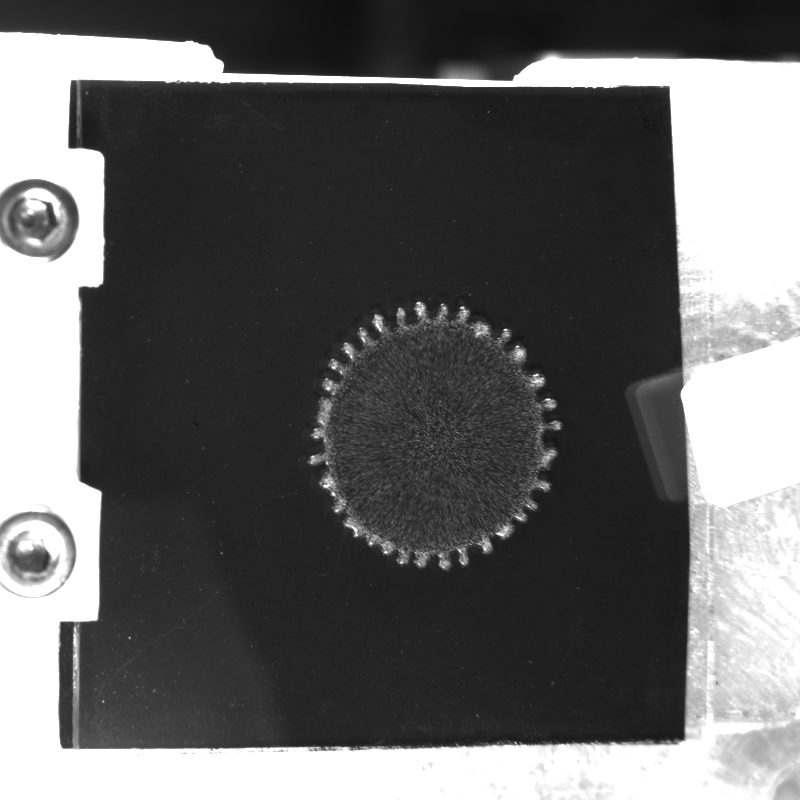

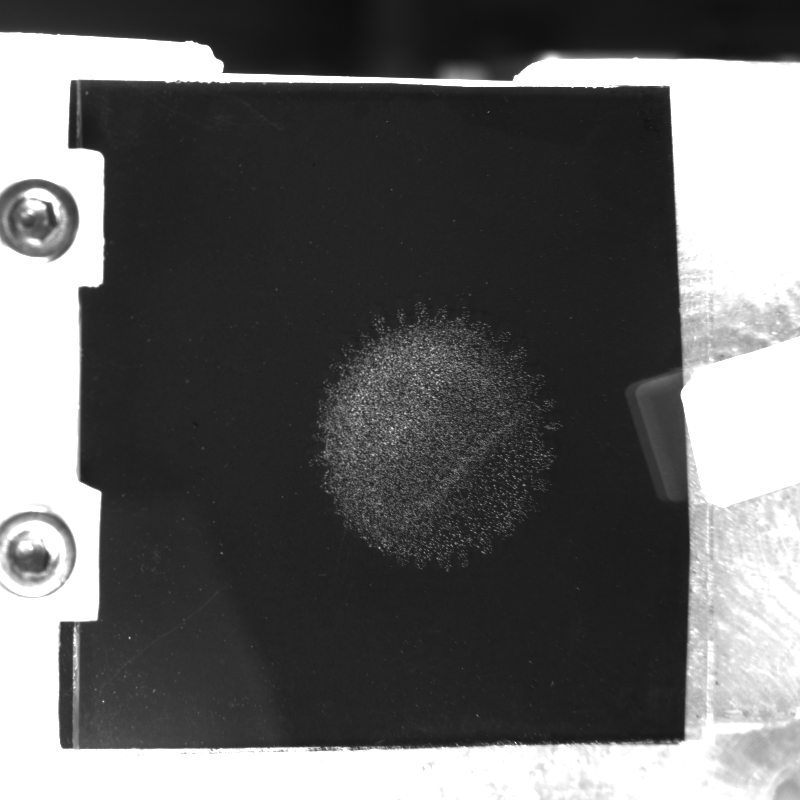

#### Test 95

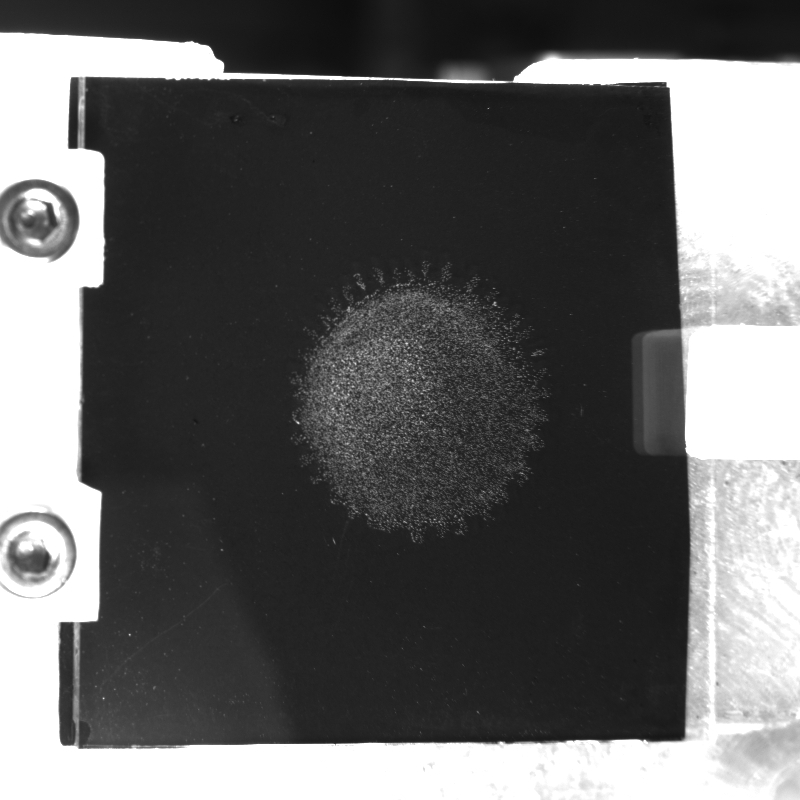

#### Test 269

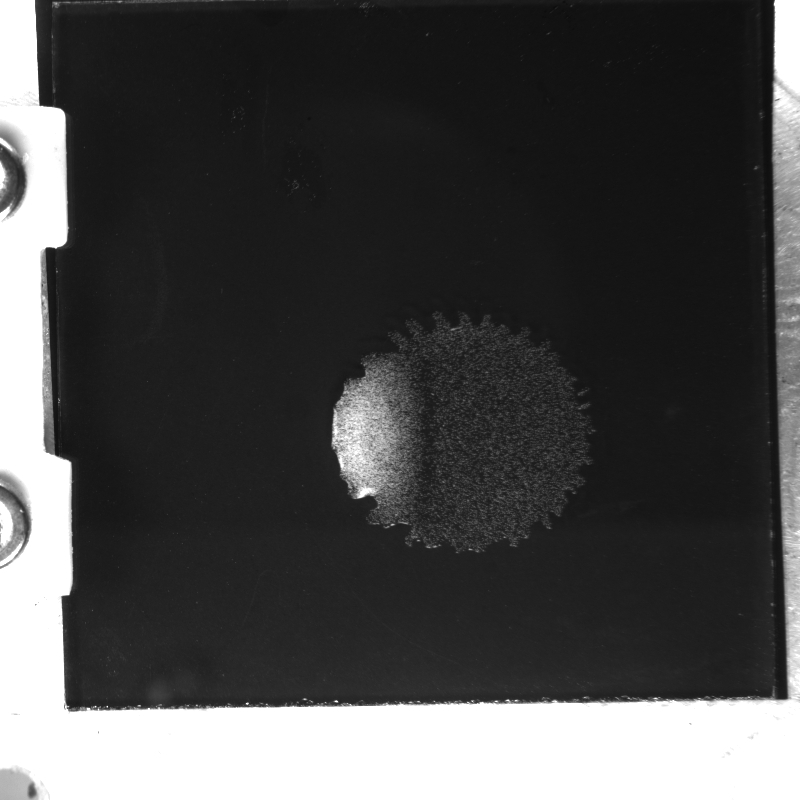

#### Test 288

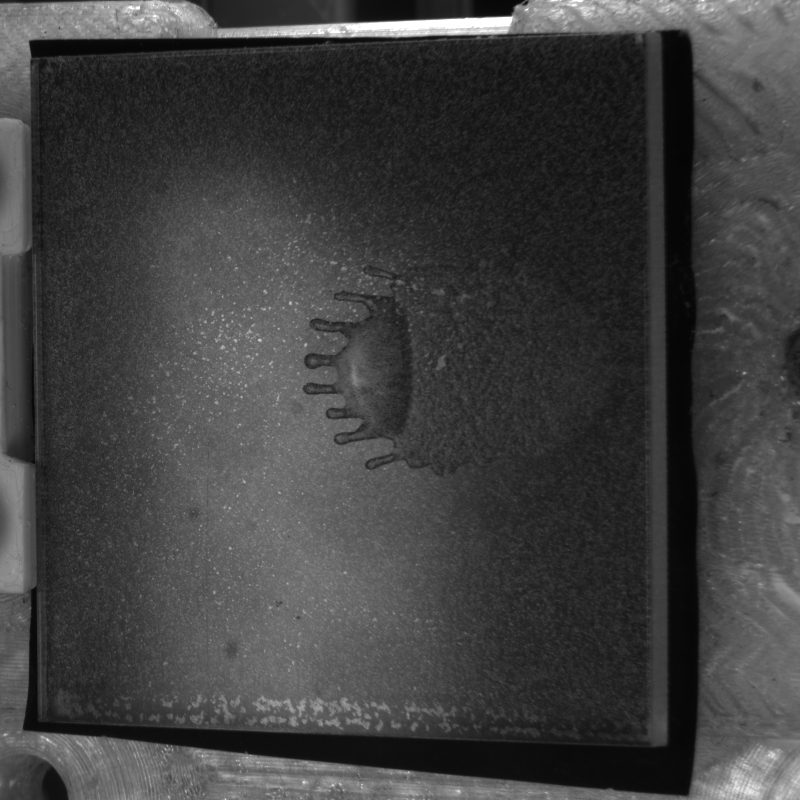

#### Test 290
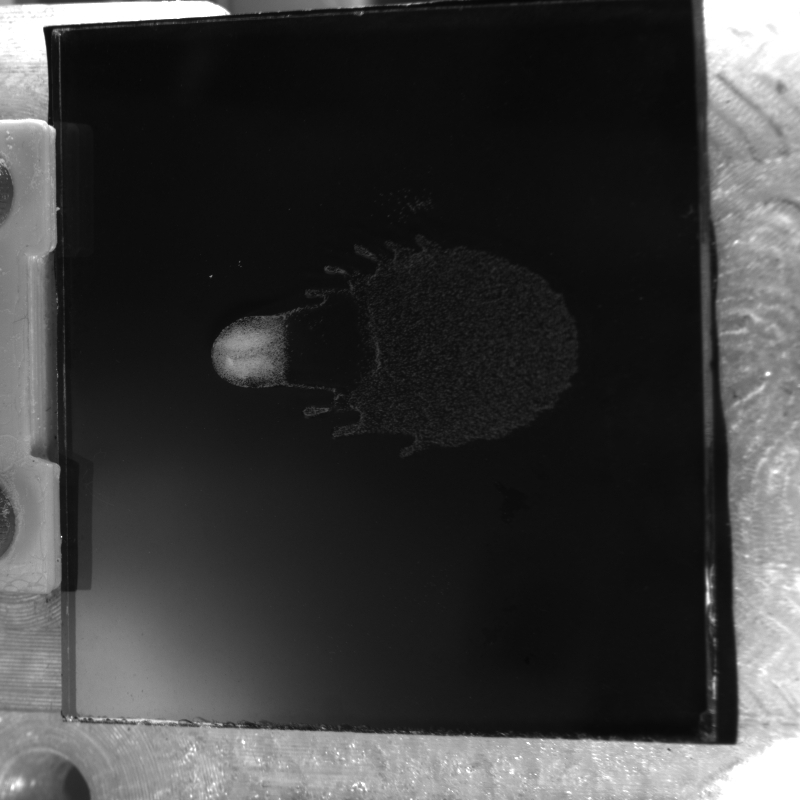

#### Test 291

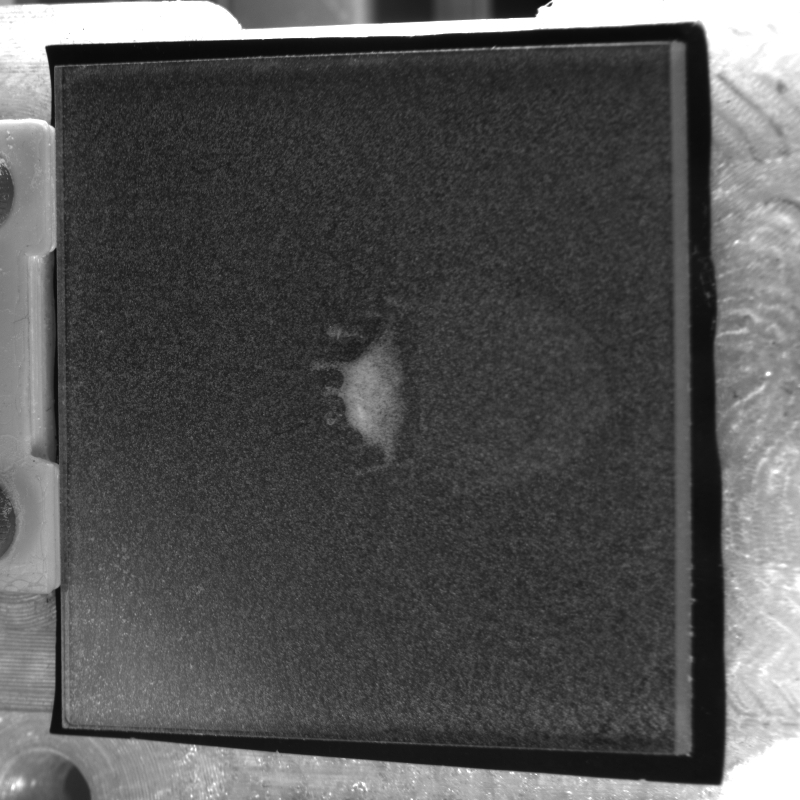

#### Test 293
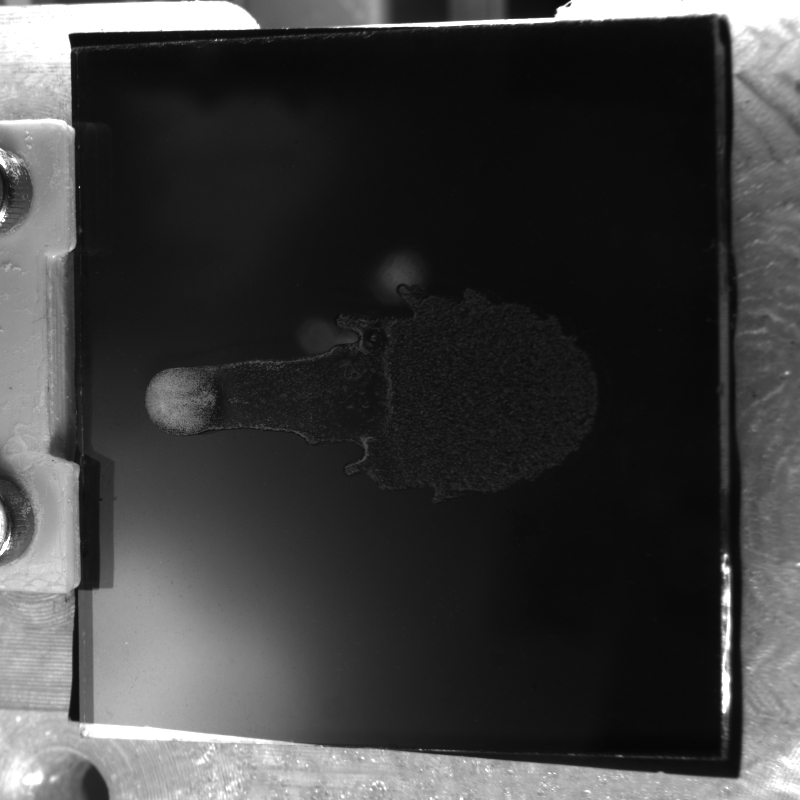

Let us consider "gear" as not net impact case

### Let us create net impact class

In [19]:
df_main['net_impact'] = 0 # By default, all cases, are not "net impact"

# Create net impact
index_net_impact = (
    set(index_no_splashing)
    .intersection(set(index_no_breaking_up))
    .difference(set(index_true_rebound))
)
df_main.loc[list(index_net_impact), 'net_impact'] = 1
df_main['net_impact'].value_counts()

net_impact
0    272
1    100
Name: count, dtype: int64

Let us check, that classes do not conflict

In [20]:
no_splashing_mask = df_main['splashing_spectrum'] == 0
no_breaking_up_mask = df_main['breaking_up'] == 0
no_true_rebound_mask = df_main['rebound'] != 2

df_main[
    no_splashing_mask & no_breaking_up_mask & no_true_rebound_mask    
]['net_impact'].value_counts()

net_impact
1    100
Name: count, dtype: int64

## Summary

Thus, 129 tests where checked. Many of them were edited. New labels creating method is more clean and understandable.
Let us show their statistics

In [21]:
label_name = [
    'net_impact', 'splashing_spectrum', 'splashing', 'breaking_up', 'rebound'
]

class_count_dict = {}

for label in label_name:
    print(df_main[label].value_counts())
    print()

net_impact
0    272
1    100
Name: count, dtype: int64

splashing_spectrum
2    185
0    132
1     55
Name: count, dtype: int64

splashing
1    240
0    132
Name: count, dtype: int64

breaking_up
0    274
1     98
Name: count, dtype: int64

rebound
0    272
1     54
2     46
Name: count, dtype: int64



In [22]:
label_name = ['net_impact', 'splashing', 'breaking_up', 'rebound']

class_count_dict = {}

for label in label_name:
    class_count_dict[label] = df_main[df_main[label]!=0].shape[0]

new_class_count_s = pd.Series(class_count_dict)
new_class_count_s

net_impact     100
splashing      240
breaking_up     98
rebound        100
dtype: int64

## Labels description:

- **splashing_spectrum**: 
    - **0 - no splashing**, when *'Number of detached small droplets during Spreading' == 0*
    - **1 - semi splashing**, when **gear** occurs, or when few droplets detach
    - **2 - splashing**. Pure splashing, when **many** droplets or **many small** droplets detach
    
- **splashing**: 1 - when *'Number of detached small droplets during Spreading' != 0*;
- **breaking_up**: when *'Number of detached small droplets during Receding or Rim merging' > 0*
- **rebound** consists of next cases:
    - **2 - true rebound**, when droplets detaching during partial rebound, or when droplet rebounds totally.
    
    *True rebound: 'Rebound' == 2 OR ('Rebound' == 1 AND 'Number of detached droplets during Rebound' > 0)*
    - **1 - jet ejection**, when true rebound does not appear.

    *'Rim merging or Central jet ejecting' == 2 AND NOT True rebound*    
    - **0** - no true rebound and no jet ejection. *Other cases*

- **net_impact**: when there is 
    - **no Splashing** (no small droplets detached during spreading, *'Number of detached small droplets during Spreading'==0*), 
    - **no Breaking up** (when *'Number of detached small droplets during Receding or Rim merging' == 0*)
    - **no True Rebound** (see True rebound definition early)

# Final preparations

In [23]:
df_main

,test,one_drop,splashing,breaking_up,net_impact,rebound,voltage,long_impulse_duration,height,inclination,...,long_impulse_dur_binary,roughness_binary,volume_fraction_binary,velocity,Re,We,We_Re,particle_droplet_diameter_ratio,particle_diameter_cat,splashing_spectrum
0,3,1,1,0,0,0,105.0,10,0.8,0,...,low,0,1,3.961141,1492.516020,1492.302356,240.108847,0.013301,small,2
1,4,1,1,0,0,0,105.0,10,0.8,0,...,low,0,1,3.961141,1492.516020,1492.302356,240.108847,0.013301,small,2
2,5,1,1,0,0,0,105.0,10,0.8,0,...,low,0,1,3.961141,1492.516020,1492.302356,240.108847,0.013301,small,2
3,7,0,1,0,0,0,105.0,10,0.8,0,...,low,0,1,3.961141,1435.111557,1434.906112,233.148786,0.013833,small,2
4,8,0,1,0,0,0,105.0,10,0.8,0,...,low,0,1,3.961141,1435.111557,1434.906112,233.148786,0.013833,small,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
367,391,0,0,0,0,2,105.0,12,0.2,20,...,low,0,1,1.980571,337.914500,227.687593,64.695100,0.082335,large,0
368,392,1,1,0,0,0,109.0,12,0.2,20,...,low,0,1,1.980571,333.867620,224.960796,64.113132,0.083333,large,1
369,393,1,1,0,0,0,107.0,12,0.2,20,...,low,0,1,1.980571,330.832459,222.915698,63.675499,0.084098,large,1
370,394,1,0,1,0,0,109.0,12,0.2,20,...,low,0,1,1.980571,338.926220,228.369293,64.840319,0.082090,large,0


## Add particle density (in kg/m^3)

In [24]:
df_main['particle_density'] = df_main['liquid_density'] * df_main['particle_liquid_density_ratio']
df_main['particle_density'] = df_main['particle_density'].round(0)
df_main['particle_density'].value_counts()

particle_density
1000.0    183
1200.0    147
450.0      23
2200.0     19
Name: count, dtype: int64

## Physical properties

$velocity = \sqrt{2g\cdot height}$

$Re=\frac{velocity \cdot droplet\_diameter \cdot liquid\_density}{viscosity}$

$We=\frac{velocity^2 \cdot droplet\_diameter \cdot liquid\_density}{surface\_tension}$

$We\_Re = We^{1/2}Re^{1/4}$

particle_droplet_diameter_ratio = particle_mean_diameter / droplet_diameter

particle_liquid_density_ratio = particle_density / liquid_density

*Params above were checked*

Let us sort columns

In [25]:
targets = ['net_impact', 'splashing']
impact_labels = ['splashing_spectrum', 'breaking_up', 'rebound']

# Unnecesary to model
generation_features = [
    'one_drop', 'voltage', 'long_impulse_duration', 'long_impulse_dur_binary'
]

# do not forget 'test'
features_original = [
    'wettability', 'roughness', 'liquid_density', 'surface_tension', 
    'viscosity', 'particle_mean_diameter', 'particle_density', 
    'volume_fraction', 'droplet_diameter', 'height', 'inclination'
]

features_aggregated = [
    'roughness_binary', 'particle_liquid_density_ratio', 
    'volume_fraction_binary', 'particle_diameter_cat', 
    'particle_droplet_diameter_ratio', 
    'velocity', 'Re', 'We', 'We_Re'
]

columns_sorted = (
    ['test'] 
    + targets 
    + impact_labels 
    + generation_features 
    + features_original 
    + features_aggregated
)
df_main = df_main[columns_sorted]
df_main.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372 entries, 0 to 371
Data columns (total 30 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   test                             372 non-null    int64  
 1   net_impact                       372 non-null    int64  
 2   splashing                        372 non-null    int64  
 3   splashing_spectrum               372 non-null    int64  
 4   breaking_up                      372 non-null    int64  
 5   rebound                          372 non-null    int64  
 6   one_drop                         372 non-null    int64  
 7   voltage                          372 non-null    float64
 8   long_impulse_duration            372 non-null    int64  
 9   long_impulse_dur_binary          372 non-null    object 
 10  wettability                      372 non-null    object 
 11  roughness                        372 non-null    float64
 12  liquid_density        

Compared to original, only two new columns were added 'particle_density', 'splashing_spectrum'

In [26]:
set(df_main.columns) - set(df_main_old.columns)

{'particle_density', 'splashing_spectrum'}

## Save full dataset

In [27]:
df_main.to_excel('../data/df_main.xlsx', index=False)